# 00 — Detection efficiency and observed blips

**Paper element.** The measured detection efficiency and candidate lists behind
Letter Fig. 2; the Letter figure itself is drawn by
`scripts/paper_fig_data_spectrum.py --stem efficiency` from the same products
(`scripts/paper_fig_efficiency.py` draws the supporting three-mode efficiency
comparison, which is not a Letter figure).

**This notebook does not run from a fresh checkout.** It is the only one that
reads the raw instrument file `data/fit_data_temp_lockin_transients_selected.hdf5`,
which is far too large to keep in git and is not distributed with the code. Without
it the first cell stops immediately with `FileNotFoundError` naming that path, and
nothing later in the notebook runs. Every other notebook here reads the tracked
data release in `release/` and needs no file from outside the repository.

The measured products behind the search, following the recipe in
`data/analyse_transients_data.ipynb` (also not distributed):

1. **Efficiency curves** — the analytic per-segment detection efficiency for
   mode $n$ under the calibrated $\chi^2_3$ hypothesis, averaged over segments.
   These curves are **marginalised over the impulse arrival
   phase $w$** — where inside the sampling interval the kick happens to land
   (detector group, August 2026) — and supersede the earlier product, which
   fixed $w = 1$, a single arrival phase. Averaging over the phase costs
   efficiency through the turn-on and leaves the saturated plateau essentially
   unchanged, so the fixed phase was the optimistic one.
2. **Blips** — the `upcrossings_{n}` (contiguous runs of transient statistic
   $q>100$). Each blip's kick amplitude `transient_dv_hat` is turned into an
   imparted momentum in eV/$c$; every up-crossing reconstructed above the
   **100 GeV (0.1 TeV) reconstruction threshold** is written to the per-mode
   `data_mode{n}.txt` candidate lists.

**Two thresholds, and they are not the same number.** 100 GeV is the
*reconstruction* threshold: the lowest imparted momentum at which an
up-crossing is reconstructed at all, and therefore what the stored lists
contain — every reconstructed candidate above it, nothing removed. The
*analysis window* the limit is set in opens an order of magnitude higher, at
`config.Q_THRESH` = 1 TeV. That edge is a stated momentum threshold, not a
point read off the efficiency curve: with the arrival-phase-marginalised
curves the window opens where mode 1 is at $\varepsilon = 0.16$ (half
efficiency at 1.22 TeV) and mode 2 at 0.58 (half at 0.95 TeV), while mode 3 is
still on the toe of its turn-on there ($\varepsilon \approx 0$ at 1 TeV, half
at 5.46 TeV). Whatever the efficiency is at a given momentum is folded into
the rate at that momentum, so the window fixes which momenta the search speaks
for, not how well it responds inside them. The limit is set on the subset
of these candidates that falls inside that window: all 8 mode-1 night
candidates (1.52–12.8 TeV) and all 126 mode-3 ones, but 24 of the 26 mode-2
candidates — the two sub-TeV mode-2 impulses, at 554 and 946 GeV, sit below the
window and take no part in setting the limit.

> **Selection caveat.** The raw file `data/fit_data_temp_lockin_transients_selected.hdf5`
> holds the **full run** — all 3122 segments, 66/99/443 blips. The analysis runs on the
> **night-time selection** (segments starting 19:00–07:00 local, minus 19–20 Jan 2026 and
> the lock-in-drive-on segments): 8/26/126 candidates over 219.66 h. That selection is not
> reconstructable from this file (the drive-on veto is not a column here), so the candidate
> lists are **read** from `data_mode{n}.txt` rather than recomputed here. The efficiency
> curves are read too, from `luhdm.efficiency` (`LUHDM_EFFICIENCY_NPZ`), exactly as the
> detector group delivered them.
> The one thing still shown for the full run is the **blip momentum spectrum** below, which
> needs the sub-window blips that only the raw file carries — it is labelled as such.

Natural-unit momentum: $p_{[\rm eV/}c] = p_{\rm SI}\,(c/e)$ (SI kg m s$^{-1}$ $\to$ eV/$c$; momentum, not energy).

These three products — the per-mode efficiency $\varepsilon(q)$, the candidate
lists `data_mode{n}.txt`, and the live-time below — are the inputs to the limit
notebooks: [`01_limit_contour.ipynb`](01_limit_contour.ipynb) (one mode),
[`04_mode_comparison.ipynb`](04_mode_comparison.ipynb) (all three overlaid), and
[`05_composite.ipynb`](05_composite.ipynb) (composite, no atmosphere).

In [1]:
%matplotlib inline
from pathlib import Path
import os as _os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from luhdm import config, efficiency as _eff

for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)

def save_figure(fig, name, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number prefix.
    # No data-release stamp, unlike notebooks 01-05: this notebook reads the raw
    # transient file directly and never opens the cube, so there is no release
    # version for its figures to name.
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)

DATA = Path("..") / "data"
MODES = (1, 2, 3)
COLORS = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}  # one colour per mode
Q_STAT_THRESHOLD = 100   # transient statistic q defining an up-crossing (a blip)
Q_RECO_TEV = 0.1         # reconstruction threshold [TeV/c]: every up-crossing
                         # above it is stored in the candidate lists
Q_WINDOW_TEV = config.Q_THRESH / 1e3   # analysis window opens here [TeV/c];
                                       # the limit uses only candidates above it

# momentum unit conversions
C_LIGHT = 2.99792458e8       # m/s
E_CHARGE = 1.602176634e-19   # J/eV
EV_PER_SI = C_LIGHT / E_CHARGE          # p[eV/c] = p[kg m/s]*this (momentum, NU)
TEV_PER_SI = EV_PER_SI / 1e12           # p[TeV/c] = p[kg m/s]*this

df = pd.read_hdf(DATA / "fit_data_temp_lockin_transients_selected.hdf5")

# Momentum bins of the detector group's efficiency product, in SI. Taken from
# the committed copy inside the package (the arrival-phase-marginalised curves),
# so this cell needs nothing from data/ except the raw transient file above.
EFF_PRODUCT = (Path(_eff.__file__).resolve().parent / "reference_data"
               / "efficiency_curves_marginalise_w.npz")
with np.load(EFF_PRODUCT) as _z:
    DV_BINS = {n: _z[f"dv_bins_{n}"].copy() for n in MODES}  # p [kg m/s]

# dv_bins_n = |dv|[volts] * K_n, with |dv| = logspace(-6,-3); recover K_n (SI/volt)
_dv_volts = np.logspace(-6, -3, 400)
K_VOLT_TO_SI = {n: float(np.median(DV_BINS[n] / _dv_volts)) for n in MODES}
print("volt->momentum K_n [kg m s^-1 / V]:",
      {n: f'{K_VOLT_TO_SI[n]:.3e}' for n in MODES})

# The efficiency curves changed; the momentum grid they are tabulated on did
# not. Check that against the earlier (w = 1) product when it is on hand, so the
# blip calibration below is demonstrably untouched by the change of curves.
_earlier = DATA / "selected_data_efficiency_curves.npz"
if _earlier.exists():
    with np.load(_earlier) as _z:
        _same = all(np.array_equal(DV_BINS[n], _z[f"dv_bins_{n}"]) for n in MODES)
    assert _same, "momentum grids differ between efficiency products: recheck K_n"
    print("dv_bins identical to the earlier w = 1 product -> K_n unchanged")
else:
    print("earlier efficiency product not present; K_n cross-check skipped")

# ---------------------------------------------------------------------------
# The two analysis products, read rather than recomputed. The raw HDF5 above is
# the FULL run (every segment); the candidate lists are the night-time
# selection, and neither that segment selection nor the lock-in-drive veto is
# reconstructable from this file. Both are therefore taken exactly as the limit
# scans read them:
#   * luhdm.efficiency.load_curve -> LUHDM_EFFICIENCY_NPZ (committed table)
#   * data_mode{n}.txt beside this notebook (night candidates)
# ---------------------------------------------------------------------------
EFF_TABLE = {n: _eff.load_curve(n, df=3) for n in MODES}   # (q_GeV, epsilon)
CANDIDATES = {n: np.sort(np.loadtxt(f"data_mode{n}.txt")) for n in MODES}
_tbl = Path(_eff.table_path())
_repo = Path(_eff.__file__).resolve().parents[1]   # the package sits in the repo
print("efficiency table       :",
      _tbl.relative_to(_repo) if _tbl.is_relative_to(_repo) else _tbl.name)
print("night candidates       :",
      {n: CANDIDATES[n].size for n in MODES})
print("  of those, in window  :",
      {n: int((CANDIDATES[n] >= Q_WINDOW_TEV * 1e12).sum()) for n in MODES})

volt->momentum K_n [kg m s^-1 / V]: {1: '1.691e-11', 2: '2.004e-11', 3: '1.371e-10'}
dv_bins identical to the earlier w = 1 product -> K_n unchanged
efficiency table       : luhdm/reference_data/efficiency_curves.npz
night candidates       : {1: 8, 2: 26, 3: 126}
  of those, in window  : {1: 8, 2: 24, 3: 126}


## Units & conversion: volts → momentum

Every observable here is a **momentum** (the momentum transfer $q$). In natural
units momentum is written in eV but is strictly **eV/$c$** — not energy.

The HDF5 gives each blip's kick amplitude `transient_dv_hat` in lock-in “volts”. The chain to momentum is

$$ |\hat{dv}|\;[\mathrm{V}] \;\xrightarrow{\times K_n}\; p\;[\mathrm{kg\,m\,s^{-1}}] \;\xrightarrow{\times\,c/e}\; p\;[\mathrm{eV}/c] \;\xrightarrow{\div 10^9}\; q\;[\mathrm{GeV}/c]. $$

- **$K_n$** (volts → SI momentum) $= \mathrm{conversion\_m\_V}_n \cdot f_n \cdot 2\pi \cdot m_{\rm sensor}$ (volts→displacement→velocity→momentum).
  We recover it empirically rather than hardcoding those constants: the
  efficiency product's `dv_bins_{n}` are exactly `np.logspace(-6, -3, 400) * K_n`,
  so `K_VOLT_TO_SI[n] = median(dv_bins_n / dv_volts)` — values ≈ 1.7e-11,
  2.0e-11, 1.4e-10 kg m s$^{-1}$/V. Those bins are the same array in the
  arrival-phase-marginalised product as in the earlier one (only the
  efficiencies on the grid moved), which the cell above asserts: the blip
  momenta below are calibrated exactly as they were.
- **$c/e = 1.8711\times10^{27}$** (`EV_PER_SI`) turns SI momentum into eV/$c$ —
  the single factor of $c$ ($1\,\mathrm{GeV}/c = 5.344\times10^{-19}$ kg m/s).
- The per-mode `data_mode{n}.txt` store $p$ in eV/$c$; the limit scan reads them,
  divides by $10^9$ to get $q$ in GeV/$c$, and works inside its analysis window
  from `config.Q_THRESH` = 1 TeV upwards.

## Efficiency curves

Drawn from the table the limit scans themselves load (`luhdm.efficiency`), so
the curve shown here and the curve folded into the rate are the same object.
These are the curves **marginalised over the impulse arrival phase $w$**
(detector group, August 2026): they replace the earlier product, which fixed
$w = 1$, and the change is confined to the turn-on — mode 1 reaches half
efficiency at 1.22 TeV rather than 0.96 TeV, and $\varepsilon$ at 1 TeV drops
from 0.59 to 0.16. The dashed line marks where the analysis window opens, so
the turn-on and the window can be read against each other.

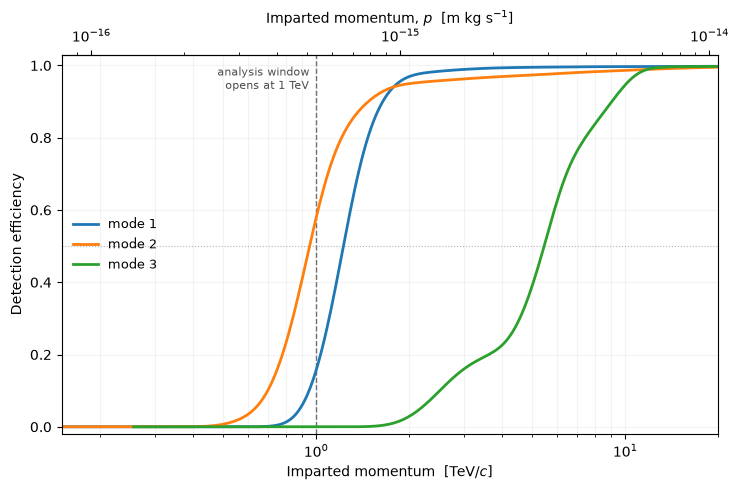

mode 1: eps = 0.5 at q =  1224.2 GeV = 1.224 TeV; eps(1 TeV) = 0.158; plateau = 0.998
mode 2: eps = 0.5 at q =   951.3 GeV = 0.951 TeV; eps(1 TeV) = 0.580; plateau = 0.999
mode 3: eps = 0.5 at q =  5459.6 GeV = 5.460 TeV; eps(1 TeV) = 0.000; plateau = 1.000


In [2]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for n in MODES:
    q_gev, eff3 = EFF_TABLE[n]              # the table the limit scans load
    ax.plot(q_gev / 1e3, eff3, color=COLORS[n], lw=2.0, label=f"mode {n}")
ax.set_xscale("log")
ax.set_xlim(0.15, 20)
ax.set_ylim(-0.02, 1.03)
ax.axhline(0.5, color="0.7", lw=0.8, ls=":", zorder=0)
ax.axvline(Q_WINDOW_TEV, color="0.4", lw=1.0, ls="--", zorder=0)
ax.text(Q_WINDOW_TEV * 0.95, 1.0, f"analysis window\nopens at {Q_WINDOW_TEV:g} TeV",
        ha="right", va="top", fontsize=8, color="0.3")
ax.set_xlabel(r"Imparted momentum  [TeV/$c$]")
ax.set_ylabel("Detection efficiency")
ax.grid(True, which="both", alpha=0.15)
ax.legend(loc="center left", frameon=False, fontsize=9)
sec = ax.secondary_xaxis("top",
                         functions=(lambda t: t / TEV_PER_SI,
                                    lambda s: s * TEV_PER_SI))
sec.set_xlabel(r"Imparted momentum, $p$  [m kg s$^{-1}$]")
fig.tight_layout()
save_figure(fig, "00_efficiency_curves")
plt.show()

# 50% points and the efficiency where the window opens, for the record
for n in MODES:
    q_gev, eff3 = EFF_TABLE[n]
    q50 = float(np.interp(0.5, eff3, q_gev))
    eps_edge = float(np.interp(config.Q_THRESH, q_gev, eff3))
    print(f"mode {n}: eps = 0.5 at q = {q50:7.1f} GeV = {q50 / 1e3:.3f} TeV; "
          f"eps({config.Q_THRESH / 1e3:g} TeV) = {eps_edge:.3f}; "
          f"plateau = {eff3.max():.3f}")

## Exposure

Two numbers, and they are different. The dataframe's per-segment `exposure_s`
sums to the **full-run** live-time (≈ 469.7 h over 3122 segments). The limit
scans assume the **night-selection** live-time, `config.T_EXPOSURE`
(= 790778 s = 219.66 h, overridable via `LUHDM_T_EXPOSURE`), so that the
notebooks and the cluster scripts share a single value.

In [3]:
exposure_s = df["exposure_s"].sum()
t0 = pd.to_datetime(df["start_time"]).min()
t1 = pd.to_datetime(df["end_time"]).max()
calendar_s = (t1 - t0).total_seconds()
print("FULL RUN (this raw file)")
print(f"segments               : {len(df)}")
print(f"exposure (from df)     : {exposure_s:.3e} s")
print(f"                       = {exposure_s / 3600:.1f} h")
print(f"                       = {exposure_s / 86400:.2f} days")
print(f"calendar span          : {t0:%Y-%m-%d} → {t1:%Y-%m-%d} "
      f"({calendar_s / 86400:.1f} days)")
print(f"duty cycle             : {exposure_s / calendar_s:.1%}")
print()
print("NIGHT SELECTION (what the limit scans assume)")
print(f"config.T_EXPOSURE      : {config.T_EXPOSURE:.6g} s")
print(f"                       = {config.T_EXPOSURE / 3600:.2f} h")
print(f"fraction of the run    : {config.T_EXPOSURE / exposure_s:.1%}")

FULL RUN (this raw file)
segments               : 3122
exposure (from df)     : 1.691e+06 s
                       = 469.7 h
                       = 19.57 days
calendar span          : 2025-12-22 → 2026-01-21 (30.0 days)
duty cycle             : 65.3%

NIGHT SELECTION (what the limit scans assume)
config.T_EXPOSURE      : 790778 s
                       = 219.66 h
fraction of the run    : 46.8%


## Blips: reconstructed momentum (full run)

For every up-crossing, the blip momentum is taken at its most significant sample
(peak $q$): $p = |\hat{dv}|\,K_n\,c/e$, with $K_n$ the volt→momentum factor
recovered above. The result is one momentum per blip, per mode, in eV/$c$ —
over **every** segment in the raw file, i.e. the full run. All of them clear
the 100 GeV reconstruction threshold by a wide margin — the softest blip in the
run is 0.47 TeV — so the count that matters for the limit is how many also fall
inside the 1 TeV analysis window, printed alongside.

In [4]:
def blip_momenta_eV(mode):
    """Reconstructed momentum [eV/c] of every q>100 up-crossing in one mode."""
    K = K_VOLT_TO_SI[mode]
    out = []
    q_col = df[f"transient_q_{mode}"]
    dv_col = df[f"transient_dv_hat_{mode}"]
    up_col = df[f"upcrossings_{mode}"]
    for q, dv, ups in zip(q_col, dv_col, up_col):
        if not len(ups):
            continue
        q = np.asarray(q)
        dv = np.asarray(dv)
        for start_i, end_i in ups:
            k = start_i + int(np.argmax(q[start_i:end_i + 1]))  # peak-q sample
            p_si = abs(dv[k]) * K
            out.append(p_si * EV_PER_SI)
    return np.array(sorted(out))

ALL_MOMENTA = {n: blip_momenta_eV(n) for n in MODES}
# every reconstructed blip is a candidate; the analysis window keeps a subset
MOMENTA = {n: ALL_MOMENTA[n][ALL_MOMENTA[n] >= Q_WINDOW_TEV * 1e12]
            for n in MODES}
for n in MODES:
    p = ALL_MOMENTA[n]
    below = int((p < Q_RECO_TEV * 1e12).sum())
    print(f"mode {n}: {p.size:3d} blips, "
          f"{below} below {Q_RECO_TEV:g} TeV reconstruction, "
          f"{MOMENTA[n].size:3d} inside the {Q_WINDOW_TEV:g} TeV window, "
          f"p = {p.min() / 1e12:.2f} .. {p.max() / 1e12:.1f} TeV "
          f"(median {np.median(p) / 1e12:.2f} TeV)")

mode 1:  66 blips, 0 below 0.1 TeV reconstruction,  64 inside the 1 TeV window, p = 0.86 .. 126.5 TeV (median 2.14 TeV)
mode 2:  99 blips, 0 below 0.1 TeV reconstruction,  79 inside the 1 TeV window, p = 0.47 .. 175.9 TeV (median 1.43 TeV)
mode 3: 443 blips, 0 below 0.1 TeV reconstruction, 443 inside the 1 TeV window, p = 1.57 .. 496.8 TeV (median 2.92 TeV)


## Blip momentum spectrum (full run)

**This figure is the full run, not the night selection.** It is the only place
the blips below the analysis window appear, and they exist only in the raw file,
which carries no night flag. The legend counts are therefore all the full-run
blips (66/99/443), *not* the 8/26/126 night candidates the limits are set on.
Making this panel night-consistent needs the segment-level selection
(start-hour window, the 19–20 Jan exclusion, the lock-in-drive veto) applied to
the raw file — that logic lives upstream, not here.

The shaded band is momentum below the 1 TeV analysis window: reconstructed and
recorded, but outside the range the limit is set in. The 100 GeV reconstruction
threshold is off the left edge of the plot, a factor of five below the softest
blip in the run (0.47 TeV) — nothing in this dataset was reconstructed near it.

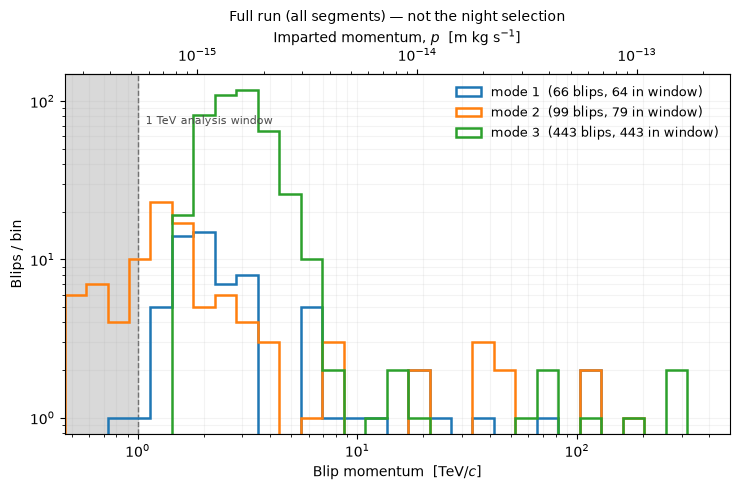

In [5]:
all_p = np.concatenate([ALL_MOMENTA[n] for n in MODES]) / 1e12  # TeV
bins = np.logspace(np.log10(all_p.min()), np.log10(all_p.max()), 32)

fig, ax = plt.subplots(figsize=(7.5, 5))
for n in MODES:
    ax.hist(ALL_MOMENTA[n] / 1e12, bins=bins, histtype="step", lw=1.8,
            color=COLORS[n],
            label=f"mode {n}  ({ALL_MOMENTA[n].size} blips, "
                  f"{MOMENTA[n].size} in window)")
ax.axvspan(bins[0], Q_WINDOW_TEV, color="0.85", zorder=0)
ax.axvline(Q_WINDOW_TEV, color="0.4", lw=1.0, ls="--", zorder=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(bins[0], bins[-1])
ax.set_xlabel(r"Blip momentum  [TeV/$c$]")
ax.set_ylabel("Blips / bin")
ax.set_title("Full run (all segments) — not the night selection", fontsize=10)
ax.grid(True, which="both", alpha=0.15)
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.text(Q_WINDOW_TEV, ax.get_ylim()[1] * 0.55,
        f"  {Q_WINDOW_TEV:g} TeV analysis window",
        ha="left", va="top", fontsize=8, color="0.3")
sec = ax.secondary_xaxis("top",
                         functions=(lambda t: t / TEV_PER_SI,
                                    lambda s: s * TEV_PER_SI))
sec.set_xlabel(r"Imparted momentum, $p$  [m kg s$^{-1}$]")
fig.tight_layout()
save_figure(fig, "00_blip_momentum_spectrum")
plt.show()

## Night candidate list (eV), per mode — everything reconstructed above 100 GeV

These are the stored lists in full: every night-selected up-crossing above the
0.1 TeV reconstruction threshold. The limit is set on the part of each list at
1 TeV and above, which is all of mode 1 and mode 3 and all but the first two
entries of mode 2 (0.55 and 0.95 TeV).

In [6]:
# compact view in TeV (full-precision eV lists live in data_mode{n}.txt)
for n in MODES:
    p_tev = CANDIDATES[n] / 1e12
    print(f"# mode {n} — {p_tev.size} night candidates [TeV/$c$]")
    print(np.array2string(p_tev, precision=2, separator=", ",
                          max_line_width=100, threshold=10_000))
    print()

# mode 1 — 8 night candidates [TeV/$c$]
[ 1.52,  1.73,  2.03,  2.86,  3.25,  3.51,  6.91, 12.79]

# mode 2 — 26 night candidates [TeV/$c$]
[0.55, 0.95, 1.02, 1.02, 1.11, 1.13, 1.15, 1.18, 1.19, 1.22, 1.31, 1.36, 1.4 , 1.43, 1.45, 1.51,
 1.58, 1.74, 2.  , 2.12, 2.43, 2.53, 2.68, 3.84, 4.28, 8.47]

# mode 3 — 126 night candidates [TeV/$c$]
[ 1.57,  1.6 ,  1.63,  1.67,  1.7 ,  1.74,  1.74,  1.76,  1.76,  1.78,  1.79,  1.81,  1.83,  1.84,
  1.86,  1.87,  1.87,  1.9 ,  1.94,  1.94,  1.94,  1.95,  1.96,  1.98,  2.01,  2.02,  2.03,  2.03,
  2.05,  2.06,  2.07,  2.11,  2.13,  2.14,  2.17,  2.18,  2.18,  2.19,  2.19,  2.23,  2.23,  2.24,
  2.26,  2.27,  2.31,  2.32,  2.34,  2.36,  2.37,  2.38,  2.39,  2.39,  2.39,  2.41,  2.42,  2.43,
  2.46,  2.5 ,  2.51,  2.55,  2.59,  2.6 ,  2.65,  2.69,  2.71,  2.71,  2.75,  2.75,  2.75,  2.78,
  2.78,  2.8 ,  2.82,  2.85,  2.85,  2.86,  2.92,  2.95,  2.96,  2.96,  2.99,  3.  ,  3.  ,  3.  ,
  3.05,  3.05,  3.06,  3.11,  3.13,  3.15,  3.24,  3.26,  3.27,  3

## Per-mode candidate files

`data_mode{n}.txt` holds each mode's night-selected candidates (impulses in eV,
one per line, every one reconstructed above the 0.1 TeV threshold) — the
per-mode analysis inputs the limit scans read via
`scan_grid.py --mode n --data data_mode{n}.txt`. The files are deliberately not
pre-cut to the analysis window: the scan reads the whole list and lays its
momentum grid from `config.Q_THRESH` = 1 TeV upwards, so anything below the
window falls outside the optimum interval's support and contributes nothing to
the limit. Moving the window is then a change of one number, not a
regeneration of the data. The files are produced by the night-selection
pipeline, **not** by this notebook: rerunning it must not overwrite them with
the full-run population, so the cell below only reads them back and checks them.

In [7]:
# These files are NOT written here: they are the night-selection product and
# this notebook only sees the full run (see the note above). Read them back and
# check they are self-consistent instead.
for n in MODES:
    p = CANDIDATES[n]
    assert p.size and np.all(p >= Q_RECO_TEV * 1e12), \
        f"data_mode{n}.txt has an entry below the {Q_RECO_TEV:g} TeV reconstruction threshold"
    in_window = p[p >= Q_WINDOW_TEV * 1e12]
    print(f"data_mode{n}.txt  {p.size:3d} candidates, "
          f"p = {p.min() / 1e12:.2f} .. {p.max() / 1e12:.1f} TeV "
          f"(median {np.median(p) / 1e12:.2f} TeV); "
          f"{in_window.size:3d} inside the {Q_WINDOW_TEV:g} TeV window")

# the ones the limit never sees, named explicitly
_outside = {n: CANDIDATES[n][CANDIDATES[n] < Q_WINDOW_TEV * 1e12] / 1e9
            for n in MODES}
print()
print("below the analysis window [GeV]:",
      {n: np.round(v, 0) for n, v in _outside.items()})

# show data_mode1.txt verbatim as an example
print()
print(Path('data_mode1.txt').read_text()[:600], '...')

data_mode1.txt    8 candidates, p = 1.52 .. 12.8 TeV (median 3.06 TeV);   8 inside the 1 TeV window
data_mode2.txt   26 candidates, p = 0.55 .. 8.5 TeV (median 1.41 TeV);  24 inside the 1 TeV window
data_mode3.txt  126 candidates, p = 1.57 .. 17.2 TeV (median 2.67 TeV); 126 inside the 1 TeV window

below the analysis window [GeV]: {1: array([], dtype=float64), 2: array([554., 946.]), 3: array([], dtype=float64)}

# Observed impulse candidates for the POLONAISE UHDM search, night-time
# selection: segments starting 19:00-07:00 local (CET) only, excluding
# 19-20 Jan 2026 (elevated lab vibration) and segments with the lock-in
# calibration output on. One impulse per line, in eV.
1.279069282346587891e+13
6.905106097634864258e+12
3.509634832824794434e+12
3.252445581909887695e+12
2.862015581564769531e+12
2.033730481278827881e+12
1.729392625591956055e+12
1.520664613481074463e+12
 ...
